In [24]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
X,y = make_blobs(n_samples=1000,centers=3)

In [6]:
X

array([[ -1.62097661,  -0.85478127],
       [-10.48976873,   2.11198946],
       [ -2.17195406,   5.49038484],
       ...,
       [  0.149455  ,   0.54827368],
       [ -7.948538  ,   1.46815283],
       [ -0.82011966,   1.24704076]])

## UNSUPERVISED ML

Here we arent going to use the labels . Instead we are going to use the X values and then we are going to apply some clustering algorithms and find the clusters

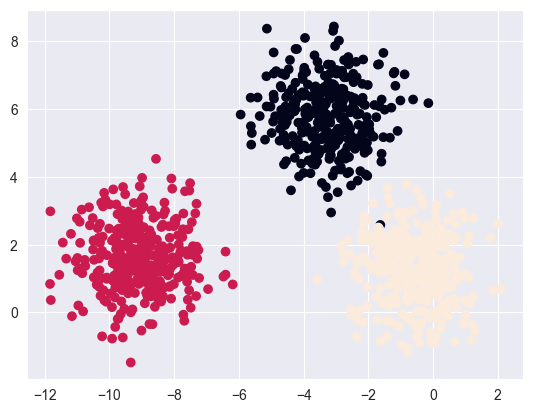

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

## Standarization

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

### We will use elbow method to select K value

In [13]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++",random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid 

In [14]:
wcss

[1599.9999999999998,
 803.5786646127408,
 205.21247616044735,
 171.22909510697292,
 162.4747832908352,
 130.31380143358814,
 122.82463154045081,
 91.7602525873496,
 82.5761054245215,
 76.35745074712914]

## Plotting the elbow curve

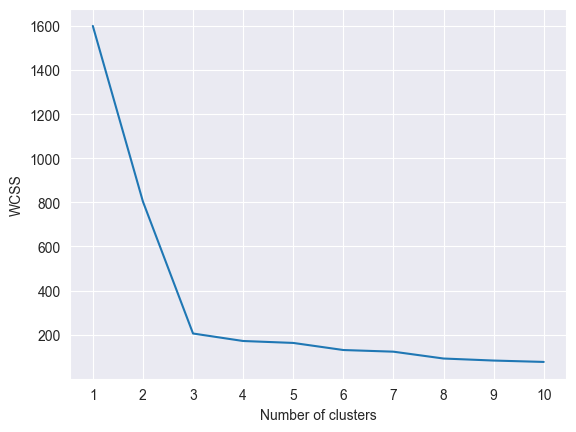

In [15]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [19]:
y_train_pred = kmeans.fit_predict(X_train_scaled)

In [20]:
y_pred  =kmeans.predict(X_test_scaled)

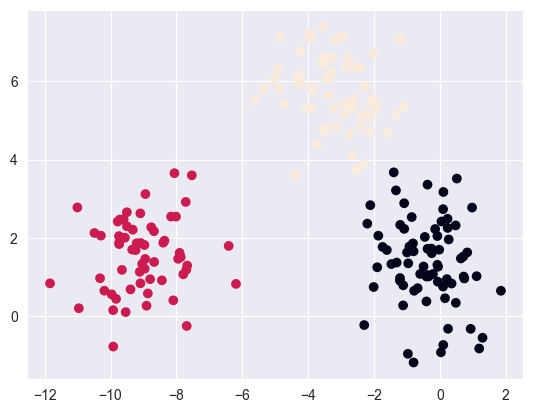

In [22]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

## VALIDATING THE VALUE OF K

### 1 - Knee Locator

In [25]:
from kneed import KneeLocator

In [26]:
kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [27]:
kl.elbow

np.int64(3)

### 2 - Silhouette Scoring

In [28]:
from sklearn.metrics import silhouette_score

In [29]:
sih_coeff = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++",random_state=42)
    kmeans.fit(X_train_scaled)
    sih_coeff.append(silhouette_score(X_train_scaled,kmeans.labels_))

In [30]:
sih_coeff

[np.float64(0.5268663886988949),
 np.float64(0.6996162105540037),
 np.float64(0.5802025998714968),
 np.float64(0.5391720465700159),
 np.float64(0.47826822845796413),
 np.float64(0.4889832463358289),
 np.float64(0.3790826195104461),
 np.float64(0.35324549547046646),
 np.float64(0.31186081945185806)]

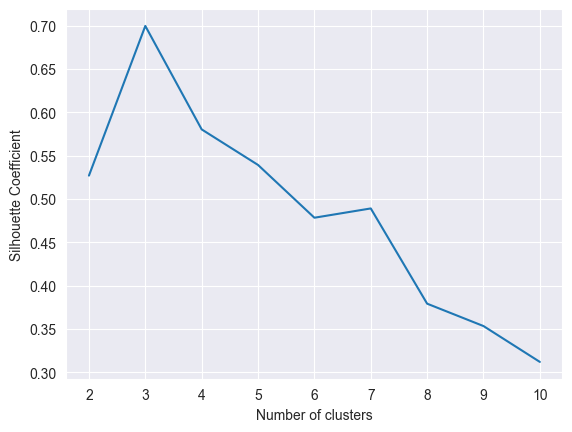

In [31]:
plt.plot(range(2,11),sih_coeff)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()